<!-- @format -->

# Phân tích tập dữ liệu

## Vấn đề chính

Tìm hiểu về tập dữ liệu tổng thể


In [2]:
# Import libraries
import pandas as pd
import numpy as np
import glob
import os
from PIL import Image
import io
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [3]:
# Load dataset từ parquet files
files = glob.glob(os.path.join('../data', '*.parquet'))
print(f"Found {len(files)} parquet files")

df = pd.concat((pd.read_parquet(f) for f in files), ignore_index=True)
print(f"Total images in dataset: {len(df)}")
print(f"Columns: {df.columns.tolist()}")

Found 9 parquet files
Total images in dataset: 10980
Columns: ['image', 'label', 'origin', 'english_label']


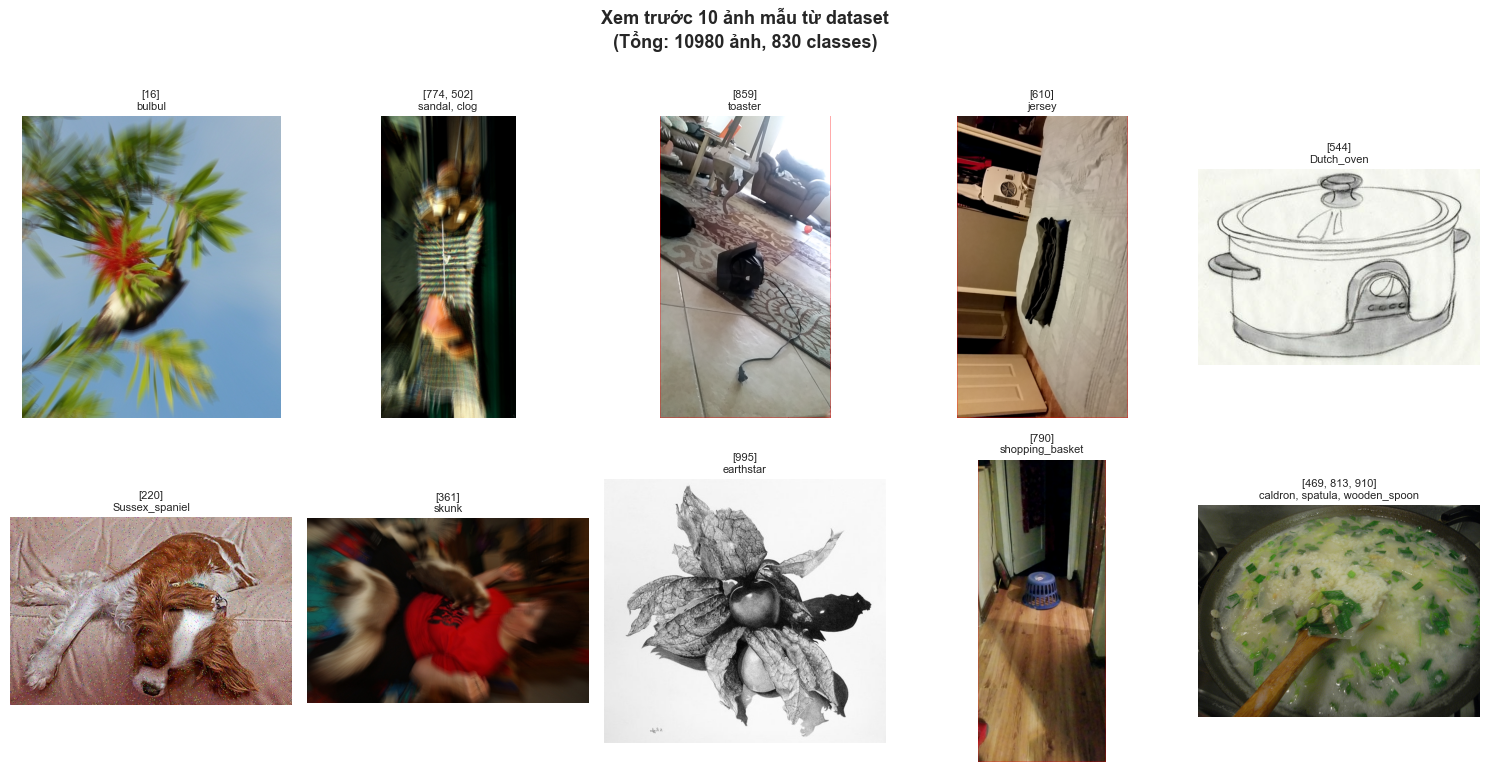

In [4]:
def bytes_to_pil(image_bytes):
    return Image.open(io.BytesIO(image_bytes)).convert('RGB')

def preview_dataset(df, n_samples=10, seed=42):
    """
    Hiển thị lưới ảnh mẫu cùng với label (ID + tên tiếng Anh).
    
    Args:
        df        : DataFrame đã load từ parquet
        n_samples : Số ảnh muốn xem trước
        seed      : Random seed để reproducible
    """
    sample = df.sample(n=min(n_samples, len(df)), random_state=seed).reset_index(drop=True)

    ncols = 5
    nrows = -(-len(sample) // ncols)  # ceiling division

    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols * 3, nrows * 3.8))
    axes = np.array(axes).reshape(nrows, ncols)

    for i, row in sample.iterrows():
        ax = axes[i // ncols, i % ncols]

        # Ảnh
        img = bytes_to_pil(row['image']['bytes'])
        ax.imshow(img)
        ax.axis('off')

        # Label IDs
        label_ids = list(row['label']) if hasattr(row['label'], '__iter__') else [row['label']]
        label_ids_str = ', '.join(str(int(l)) for l in label_ids)

        # Tên tiếng Anh
        eng = row.get('english_label', [])
        if hasattr(eng, '__iter__') and not isinstance(eng, str):
            eng_str = ', '.join(str(e) for e in eng)
        else:
            eng_str = str(eng)

        title = f"[{label_ids_str}]\n{eng_str}"
        ax.set_title(title, fontsize=8, wrap=True,
                     bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7))

    # Ẩn các ô thừa
    for j in range(len(sample), nrows * ncols):
        axes[j // ncols, j % ncols].axis('off')

    fig.suptitle(f'Xem trước {len(sample)} ảnh mẫu từ dataset\n'
                 f'(Tổng: {len(df)} ảnh, {len(set(itertools.chain.from_iterable(df["label"])))} classes)',
                 fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()

# --- Chạy preview ---
preview_dataset(df, n_samples=10, seed=42)

In [5]:
# Đếm số lượng class trong tập dữ liệu (label là array, mỗi ảnh có thể thuộc nhiều nhóm)
if 'label' in df.columns:
    all_labels = list(itertools.chain.from_iterable(df['label']))
    unique_labels = set(all_labels)
    num_classes = len(unique_labels)
    print(f"Số lượng class trong tập dữ liệu: {num_classes}")
    print(f"Các class: {sorted(unique_labels)}")
else:
    print("Không tìm thấy cột 'label' trong dữ liệu.")

Số lượng class trong tập dữ liệu: 830
Các class: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(9), np.int64(10), np.int64(11), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23), np.int64(25), np.int64(26), np.int64(27), np.int64(28), np.int64(29), np.int64(30), np.int64(31), np.int64(33), np.int64(34), np.int64(35), np.int64(36), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43), np.int64(44), np.int64(45), np.int64(46), np.int64(47), np.int64(49), np.int64(50), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(57), np.int64(58), np.int64(59), np.int64(60), np.int64(61), np.int64(62), np.int64(63), np.int64(64), np.int64(65), np.int64(66), np.int64(67), np.int64(68), np.int64(69), np.int64(71), np.int64(72), np.int64(73), np.int64(74), np.int64(75), np.int64(77), np.int64(79), np.int64(80), np.in